In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE

In [16]:
df = pd.read_csv(r"C:\Users\ME\Downloads\archive (13)\creditcard.csv")

In [19]:
print(df.shape)


(284807, 31)


In [30]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.587299,0
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.795094,0
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,2.153063,0
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.163777,0
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.296140,0


Missing values ​​and distribution

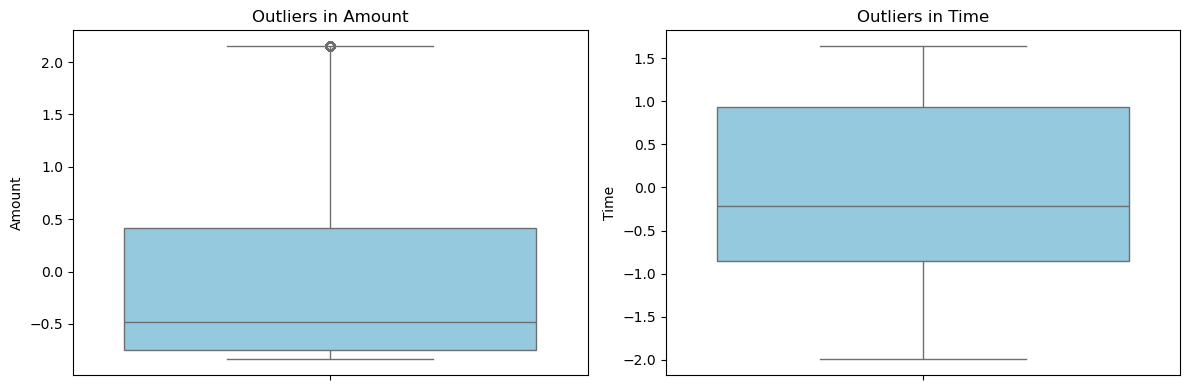

In [31]:
cols = ['Amount', 'Time']

plt.figure(figsize=(12, 4))
for i, col in enumerate(cols, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

Handling outliers

In [32]:
# معالجة القيم الشاذة
for col in ['Amount', 'Time']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

# Scale الـ Amount و Time
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

print("✅ تم معالجة القيم الشاذة والـ Scaling")
print(df[['Amount', 'Time']].describe())

✅ تم معالجة القيم الشاذة والـ Scaling
             Amount          Time
count  2.848070e+05  2.848070e+05
mean   2.235360e-17  2.107626e-16
std    1.000002e+00  1.000002e+00
min   -8.387109e-01 -1.996583e+00
25%   -7.479098e-01 -8.552120e-01
50%   -4.819924e-01 -2.131453e-01
75%    4.124793e-01  9.372174e-01
max    2.153063e+00  1.642058e+00


Imbalanced SMOTE

In [33]:
X = df.drop('Class', axis=1)
y = df['Class']

print("Before SMOTE:", y.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())
print("✅ Data is now balanced")

Before SMOTE: {0: 284315, 1: 492}
After SMOTE: {0: 284315, 1: 284315}
✅ Data is now balanced


Data division

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("✅ Data Split Done")

Train: (454904, 30)
Test: (113726, 30)
✅ Data Split Done


XGBoost Model

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



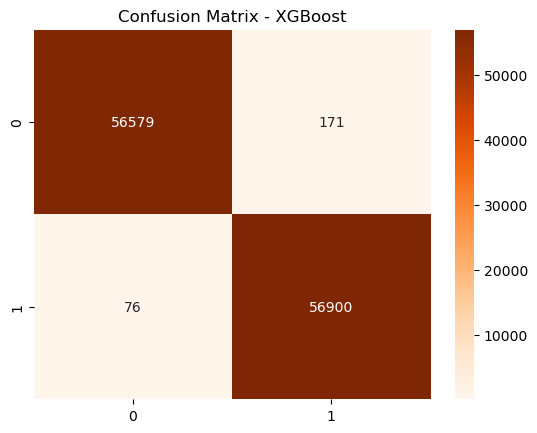

In [37]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb))

sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')
plt.show()

Isolation Forest

=== Isolation Forest Results ===
              precision    recall  f1-score   support

           0       0.50      1.00      0.67     56750
           1       0.99      0.00      0.01     56976

    accuracy                           0.50    113726
   macro avg       0.75      0.50      0.34    113726
weighted avg       0.75      0.50      0.34    113726



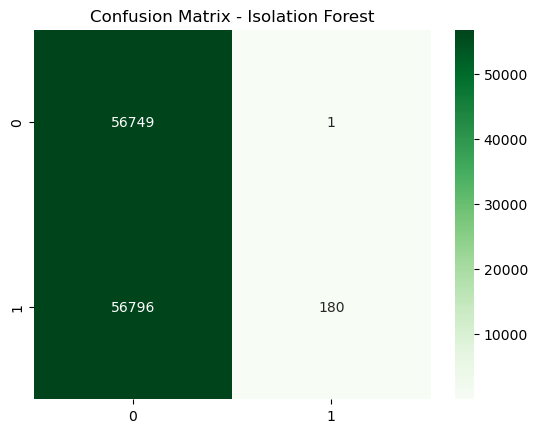

In [38]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.0017,
    random_state=42
)

iso_model.fit(X_train)

y_pred_iso = iso_model.predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

print("=== Isolation Forest Results ===")
print(classification_report(y_test, y_pred_iso))

sns.heatmap(confusion_matrix(y_test, y_pred_iso),
            annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Isolation Forest')
plt.show()

Comparing the models

              Model  F1 Score   ROC AUC
0           XGBoost  0.997834  0.997826
1  Isolation Forest  0.006298  0.501571


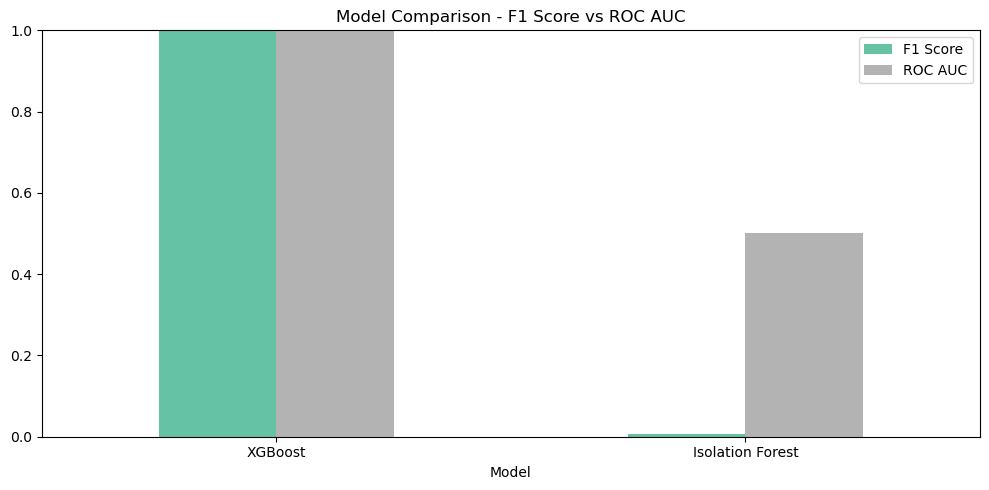

In [39]:
from sklearn.metrics import f1_score, roc_auc_score

results = {
    'Model': ['XGBoost', 'Isolation Forest'],
    'F1 Score': [
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_iso)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_pred_iso)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

results_df.set_index('Model').plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Model Comparison - F1 Score vs ROC AUC')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

 Feature Importance

C:\Users\ME\AppData\Local\Temp\ipykernel_30700\594446320.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature',


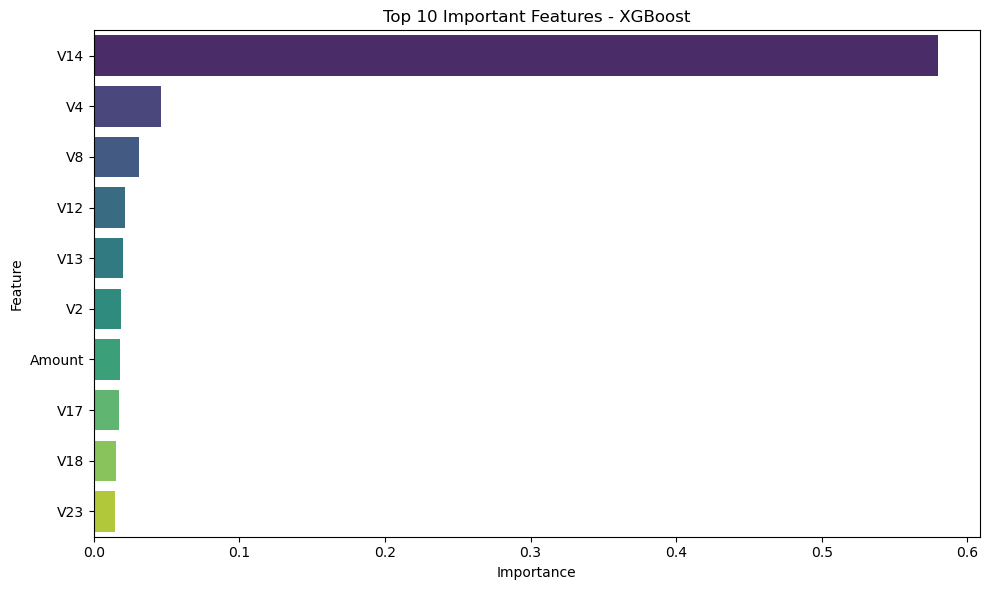

In [40]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance, palette='viridis')
plt.title('Top 10 Important Features - XGBoost')
plt.tight_layout()
plt.show()

Save the form

In [41]:
import joblib

joblib.dump(xgb_model, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model Saved Successfully!")
print("Files saved:")
print("  - fraud_model.pkl")
print("  - scaler.pkl")

✅ Model Saved Successfully!
Files saved:
  - fraud_model.pkl
  - scaler.pkl


Preparing data for Dashboard

In [42]:
# 1. توزيع الـ Fraud
fraud_dist = df['Class'].value_counts().reset_index()
fraud_dist.columns = ['Class', 'Count']
fraud_dist['Class'] = fraud_dist['Class'].map({0: 'Normal', 1: 'Fraud'})
fraud_dist.to_csv('fraud_distribution.csv', index=False)

# 2. Feature Importance
feature_importance.to_csv('feature_importance.csv', index=False)

# 3. Model Comparison
results_df.to_csv('model_comparison.csv', index=False)

# 4. Sample من الداتا للـ Dashboard
df.sample(500, random_state=42).to_csv('sample_data.csv', index=False)

print("✅ All CSV files saved!")
print("  - fraud_distribution.csv")
print("  - feature_importance.csv")
print("  - model_comparison.csv")
print("  - sample_data.csv")

✅ All CSV files saved!
  - fraud_distribution.csv
  - feature_importance.csv
  - model_comparison.csv
  - sample_data.csv
